In [1]:
#Aiming for forecasting demand per (product_id, warehouse_id)
import numpy as np
import pandas as pd


products = pd.read_csv("products.csv")
inventory = pd.read_csv("inventory.csv")
sales = pd.read_csv("sales_history.csv")
warehouses = pd.read_csv("warehouses.csv")

In [2]:
print(products.columns)
print(inventory.columns)
print(sales.columns)
print(warehouses.columns)

Index(['product_id', 'sku', 'product_name', 'category', 'unit_price',
       'created_at'],
      dtype='object')
Index(['inventory_id', 'product_id', 'warehouse_id', 'stock_level',
       'last_updated', 'reserved_stock'],
      dtype='object')
Index(['sale_id', 'product_id', 'warehouse_id', 'sale_date', 'quantity_sold',
       'revenue'],
      dtype='object')
Index(['warehouse_id', 'warehouse_name', 'city', 'warehouse_state', 'zipcode',
       'capacity'],
      dtype='object')


In [3]:
#Product table cleaning

#Removing products with duplicate IDs
products.drop_duplicates(subset=['product_id'])

#Fix category formatting
products['category'] = (
    products['category']
        .astype(str)
    .str.lower()
    .str.strip())

#Converting to datetime
products['created_at'] = pd.to_datetime(products['created_at'])

#Removing products with negative or zero unit_price
products = products[products['unit_price'] >= 0]

print(products.head(5))

   product_id      sku          product_name   category  unit_price  \
0           1  BV-0001  Sparkling Water 12pk  beverages        6.99   
1           2  BV-0002     Orange Juice 64oz  beverages        4.49   
2           3  BV-0003      Coffee Beans 1lb  beverages       12.99   
3           4  BV-0004        Green Tea 20pk  beverages        5.99   
4           5  SN-0001       Mixed Nuts 16oz     snacks        8.99   

           created_at  
0 2025-08-16 09:34:21  
1 2025-09-01 09:34:21  
2 2025-08-14 09:34:21  
3 2025-05-19 09:34:21  
4 2025-07-05 09:34:21  


In [4]:
#cleaning inventory table
#converting to datetime
inventory['last_updated'] = pd.to_datetime(inventory['last_updated'])
#Removing entries with negative stock_level
inventory = inventory[ inventory['stock_level'] > 0 ]

In [5]:
#sales history table cleaning
#Drop duplicate rows
sales.drop_duplicates(subset=['sale_id'])
#Removing invalid rows
sales = sales[ (sales['quantity_sold'] > 0) & (sales['revenue'] > 0) ]
#converting to datetime
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
#Aggregate into daily demand
sales_daily = (
    sales
    .groupby(['product_id','warehouse_id','sale_date'])
    ['quantity_sold']
    .sum()
    .reset_index()
)

sales_daily= sales_daily.rename(
    columns = {'quantity_sold':'demand'}
)


In [6]:
#Warehouse table cleaning
#Normalize city and state
warehouses['city'] = warehouses['city'].str.title().str.strip()
warehouses['warehouse_state'] = warehouses['warehouse_state'].str.title().str.strip()

#Filling missing capacity
warehouses['capacity'] = (
    warehouses['capacity']
    .fillna(warehouses['capacity'].median())
)

In [7]:
print(inventory.head(10))

   inventory_id  product_id  warehouse_id  stock_level        last_updated  \
0           377           4             1          174 2025-06-03 01:03:05   
1           414          20             1           36 2025-06-03 01:08:02   
2           381           6             1          141 2025-06-03 10:52:43   
3           389           9             2          135 2025-06-03 19:13:10   
4           390          10             2           76 2025-06-04 00:35:16   
5           412          19             3           44 2025-06-04 02:16:28   
6           427          25             3           67 2025-06-04 02:20:39   
7           393          11             1          122 2025-06-04 06:38:59   
8           421          23             1           77 2025-06-04 06:59:33   
9           370           1             4          103 2025-06-04 20:28:24   

   reserved_stock  
0              68  
1              23  
2               2  
3               2  
4              11  
5              28  
6

In [8]:
#Create Master Dataset 
#creating master table by adding sales_daily joined with corresponding products and warehouses

master = (
    sales_daily
    .merge(products, on='product_id', how='left')
    .merge(warehouses, on='warehouse_id', how='left')
)

In [9]:

master = master.sort_values('sale_date')
inventory = inventory.sort_values('last_updated')

master = pd.merge_asof(
    master,
    inventory[['product_id', 'warehouse_id','stock_level','last_updated']],
    left_on='sale_date',
    right_on='last_updated',
    by=['product_id','warehouse_id'],
    direction='backward'
)

print(master.head(5))


   product_id  warehouse_id  sale_date  demand      sku        product_name  \
0          11             3 2024-12-10      12  PS-0002           Pasta 1lb   
1           9             1 2024-12-10       7  SN-0005       Pretzels 18oz   
2          14             1 2024-12-10       5  PS-0005  Peanut Butter 16oz   
3          14             2 2024-12-10       4  PS-0005  Peanut Butter 16oz   
4           8             1 2024-12-10      27  SN-0004      Trail Mix 24oz   

  category  unit_price          created_at    warehouse_name     city  \
0   pantry        2.49 2025-09-19 09:34:21     Midwest Depot  Chicago   
1   snacks        3.99 2025-04-13 09:34:21    East Coast Hub   Newark   
2   pantry        4.49 2025-05-09 09:34:21    East Coast Hub   Newark   
3   pantry        4.49 2025-05-09 09:34:21  Southeast Center  Atlanta   
4   snacks        9.49 2025-07-10 09:34:21    East Coast Hub   Newark   

  warehouse_state  zipcode  capacity  stock_level last_updated  
0              Il    

In [10]:
# master['stock_level'] = (
#     master.groupby(['product_id','warehouse_id'])['stock_level']
#     .transform(lambda x: x.fillna(x.mean()))
# )

master['stock_level'] = (
    master.groupby(['product_id','warehouse_id'])['stock_level']
    .ffill()
)

master['last_updated'] = (
    master.groupby(['product_id','warehouse_id'])['last_updated']
    .ffill()
)

master['stock_level'] = master['stock_level'].fillna(
    master['stock_level'].mean()
)

In [11]:
print(master[np.isnan(master['stock_level'])])

Empty DataFrame
Columns: [product_id, warehouse_id, sale_date, demand, sku, product_name, category, unit_price, created_at, warehouse_name, city, warehouse_state, zipcode, capacity, stock_level, last_updated]
Index: []


In [12]:
print(master[master['last_updated']==np.datetime64('NaT') ])

Empty DataFrame
Columns: [product_id, warehouse_id, sale_date, demand, sku, product_name, category, unit_price, created_at, warehouse_name, city, warehouse_state, zipcode, capacity, stock_level, last_updated]
Index: []


In [13]:
def make_continuous(df):

    idx = pd.date_range(
        df['sale_date'].min(),
        df['sale_date'].max()
    )

    df = (
        df.set_index('sale_date')
          .reindex(idx)
          .rename_axis('sale_date')
          .reset_index()
    )

    df['demand'] = df['demand'].fillna(0)

    return df

In [14]:
#Filling empty stock_level entries with forward fill
master = (
    master
    .set_index('sale_date')
    .groupby(['product_id','warehouse_id'])
    .resample('D')
    .agg({
        'demand':'sum',
        'stock_level':'last'
    })
    .reset_index()
)

master['demand'] = master['demand'].fillna(0)

master['stock_level'] = (
    master.groupby(['product_id','warehouse_id'])['stock_level']
    .ffill()
)

In [15]:
#converting stock_levels to integer for realism
master['stock_level'] = master['stock_level'].round().astype(int)

In [16]:
master['stock_change'] = master.groupby(
    ['product_id','warehouse_id']
)['stock_level'].diff()

In [17]:
master['stockout_flag'] = (master['stock_level'] <= master['demand']).astype(int)

In [18]:
master['day_of_week'] = master['sale_date'].dt.dayofweek
master['month'] = master['sale_date'].dt.month
master['is_weekend'] = master['day_of_week'].isin([5,6]).astype(int)

In [19]:
#Improving demand density for better signals
# baseline = np.random.poisson(2, size=len(master))
# noise = np.random.randint(0,3,len(master))

# master['demand'] = baseline + noise

In [20]:
#Adding Stockout Logic
master.loc[master['stock_level'] == 0, 'demand'] = 0

In [21]:
master = master.sort_values(
    ['product_id','warehouse_id','sale_date']
)

master['lag_1'] = (
    master.groupby(['product_id','warehouse_id'])['demand']
    .shift(1)
)

master['lag_7'] = (
    master.groupby(['product_id','warehouse_id'])['demand']
    .shift(7)
)

master['rolling_mean_7'] = (
    master.groupby(['product_id','warehouse_id'])['demand']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

In [22]:
master['stockout_flag'] = (
    master['stock_level'] == 0
).astype(int)

master.dropna()

,product_id,warehouse_id,sale_date,demand,stock_level,stock_change,stockout_flag,day_of_week,month,is_weekend,lag_1,lag_7,rolling_mean_7
7,1,1,2024-12-22,9,153,0.0,0,6,12,1,26.0,17.0,18.428571
8,1,1,2024-12-23,9,153,0.0,0,0,12,0,9.0,43.0,17.285714
9,1,1,2024-12-24,0,153,0.0,0,1,12,0,9.0,4.0,12.428571
10,1,1,2024-12-25,26,153,0.0,0,2,12,0,0.0,20.0,11.857143
11,1,1,2024-12-26,0,153,0.0,0,3,12,0,26.0,3.0,12.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10954,25,4,2025-05-24,0,153,0.0,0,5,5,1,0.0,0.0,0.142857
10955,25,4,2025-05-25,0,153,0.0,0,6,5,1,0.0,0.0,0.142857
10956,25,4,2025-05-26,0,153,0.0,0,0,5,0,0.0,1.0,0.142857
10957,25,4,2025-05-27,0,153,0.0,0,1,5,0,0.0,0.0,0.000000


In [23]:
print(master.head(10))
print (master.tail(10))

   product_id  warehouse_id  sale_date  demand  stock_level  stock_change  \
0           1             1 2024-12-15      17          153           NaN   
1           1             1 2024-12-16      43          153           0.0   
2           1             1 2024-12-17       4          153           0.0   
3           1             1 2024-12-18      20          153           0.0   
4           1             1 2024-12-19       3          153           0.0   
5           1             1 2024-12-20      16          153           0.0   
6           1             1 2024-12-21      26          153           0.0   
7           1             1 2024-12-22       9          153           0.0   
8           1             1 2024-12-23       9          153           0.0   
9           1             1 2024-12-24       0          153           0.0   

   stockout_flag  day_of_week  month  is_weekend  lag_1  lag_7  rolling_mean_7  
0              0            6     12           1    NaN    NaN         

In [24]:
print(master[master['lag_1'] == master['lag_1']])

       product_id  warehouse_id  sale_date  demand  stock_level  stock_change  \
1               1             1 2024-12-16      43          153           0.0   
2               1             1 2024-12-17       4          153           0.0   
3               1             1 2024-12-18      20          153           0.0   
4               1             1 2024-12-19       3          153           0.0   
5               1             1 2024-12-20      16          153           0.0   
...           ...           ...        ...     ...          ...           ...   
10954          25             4 2025-05-24       0          153           0.0   
10955          25             4 2025-05-25       0          153           0.0   
10956          25             4 2025-05-26       0          153           0.0   
10957          25             4 2025-05-27       0          153           0.0   
10958          25             4 2025-05-28      37          153           0.0   

       stockout_flag  day_o

In [25]:
print(master['demand'].describe())
print(master['demand'].value_counts(normalize=True).head())

count    10959.000000
mean         5.539648
std          9.933133
min          0.000000
25%          0.000000
50%          0.000000
75%          8.000000
max        134.000000
Name: demand, dtype: float64
demand
0    0.542750
2    0.033397
3    0.032941
4    0.028743
1    0.028743
Name: proportion, dtype: float64


In [26]:
master.groupby(
    ['product_id','warehouse_id']
)['sale_date'].diff().value_counts().head()

sale_date
1 days    10898
Name: count, dtype: int64

In [27]:
print(master[master['stock_level'] - master['stock_level'].astype(int) > 0])

Empty DataFrame
Columns: [product_id, warehouse_id, sale_date, demand, stock_level, stock_change, stockout_flag, day_of_week, month, is_weekend, lag_1, lag_7, rolling_mean_7]
Index: []


In [28]:
#Final data cleaning before training model
master = master.sort_values(
    ['product_id','warehouse_id','sale_date']
)

master = master.dropna().reset_index(drop=True)

In [29]:
FEATURES = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'day_of_week',
    'month',
    'is_weekend',
    'stock_level',
    'stock_change',
    'stockout_flag'
]

TARGET = 'demand'

In [30]:
split_date = master['sale_date'].max() - pd.Timedelta(days=100)

train = master[master['sale_date'] <= split_date].copy()
test  = master[master['sale_date'] >  split_date].copy()

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    train[FEATURES],
    train[TARGET],
    eval_set=[(test[FEATURES], test[TARGET])],
    eval_metric='l1'
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 286
[LightGBM] [Info] Number of data points in the train set: 4540, number of used features: 6
[LightGBM] [Info] Start training from score 5.606167


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
test['pred_demand_lgb'] = model.predict(test[FEATURES])

In [36]:
mae  = mean_absolute_error(test[TARGET], test['pred_demand_lgb'])
rmse = np.sqrt(mean_squared_error(test[TARGET], test['pred_demand_lgb']))

mape = np.mean(
    np.abs(
        (test[TARGET] - test['pred_demand_lgb']) /
        np.clip(test[TARGET],1,None)
    )
) * 100

print("LightGBM MAE :", mae)
print("LightGBM RMSE:", rmse)
print("LightGBM MAPE:", mape)

LightGBM MAE : 6.070330422592042
LightGBM RMSE: 9.707668548089531
LightGBM MAPE: 284.97738578966715


In [37]:
future_days = 7
forecast_rows = []

last_data = master.copy()

for step in range(1, future_days + 1):

    next_date = last_data['sale_date'].max() + pd.Timedelta(days=1)

    future_df = (
        last_data
        .sort_values(['product_id','warehouse_id','sale_date'])
        .groupby(['product_id','warehouse_id'])
        .tail(1)
        .copy()
    )

    future_df['sale_date'] = next_date

    future_df['lag_7'] = future_df['lag_1']
    future_df['lag_1'] = future_df['demand']

    future_df['rolling_mean_7'] = (
        future_df[['lag_1','lag_7']].mean(axis=1)
    )

    future_df['day_of_week'] = future_df['sale_date'].dt.dayofweek
    future_df['month'] = future_df['sale_date'].dt.month
    future_df['is_weekend'] = future_df['day_of_week'].isin([5,6]).astype(int)

    future_df['pred_demand'] = model.predict(
        future_df[FEATURES]
    )

    future_df['demand'] = future_df['pred_demand']

    forecast_rows.append(future_df)

    last_data = pd.concat([last_data, future_df])

In [38]:
forecast_lgb = pd.concat(forecast_rows)

forecast_lgb = forecast_lgb[
    ['product_id','warehouse_id','sale_date','pred_demand']
]

In [39]:
pid = master['product_id'].unique()
wid = master['warehouse_id'].unique()

In [40]:
print(pid)
print(wid)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]
[1 2 4 3]


In [41]:
#Plotting prediction graph
#Extracting historical data
pid_ind = 15
wid_ind = 0
history = master[
    (master['product_id']==pid[pid_ind]) &
    (master['warehouse_id']==wid[wid_ind])
].sort_values('sale_date')


In [42]:
print(history)

      product_id  warehouse_id  sale_date  demand  stock_level  stock_change  \
6281          16             1 2024-12-18       5          153           0.0   
6282          16             1 2024-12-19       8          153           0.0   
6283          16             1 2024-12-20       7          153           0.0   
6284          16             1 2024-12-21       0          153           0.0   
6285          16             1 2024-12-22       0          153           0.0   
...          ...           ...        ...     ...          ...           ...   
6451          16             1 2025-06-06       0          153           0.0   
6452          16             1 2025-06-07       0          153           0.0   
6453          16             1 2025-06-08       0          153           0.0   
6454          16             1 2025-06-09       9          153           0.0   
6455          16             1 2025-06-10       1          119         -34.0   

      stockout_flag  day_of_week  month

In [43]:
#Extract forecast data
future = forecast_lgb[
    (forecast_lgb['product_id']==pid[pid_ind]) &
    (forecast_lgb['warehouse_id']==wid[wid_ind])
].sort_values('sale_date')

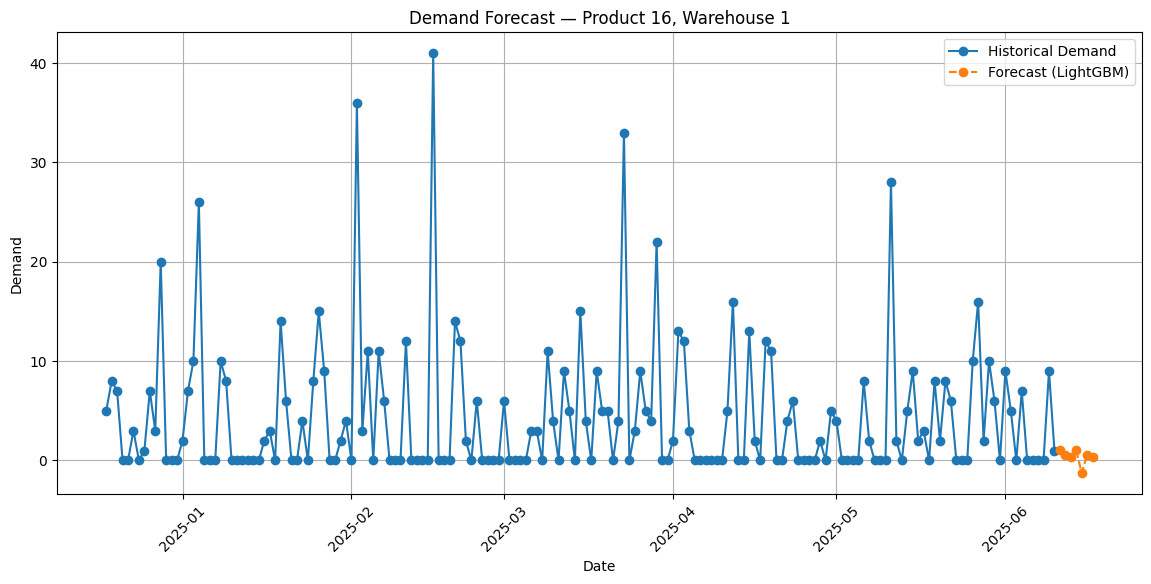

In [44]:
#Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Historical demand
plt.plot(
    history['sale_date'],
    history['demand'],
    label='Historical Demand',
    marker='o'
)

# Future forecast
plt.plot(
    future['sale_date'],
    future['pred_demand'],
    label='Forecast (LightGBM)',
    marker='o',
    linestyle='--'
)

plt.title(f"Demand Forecast — Product {pid[pid_ind]}, Warehouse {wid[wid_ind]}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [45]:
#Smooth transition
last_actual = history.tail(1)

future_plot = pd.concat([
    last_actual.rename(columns={'demand':'pred_demand'}),
    future
])

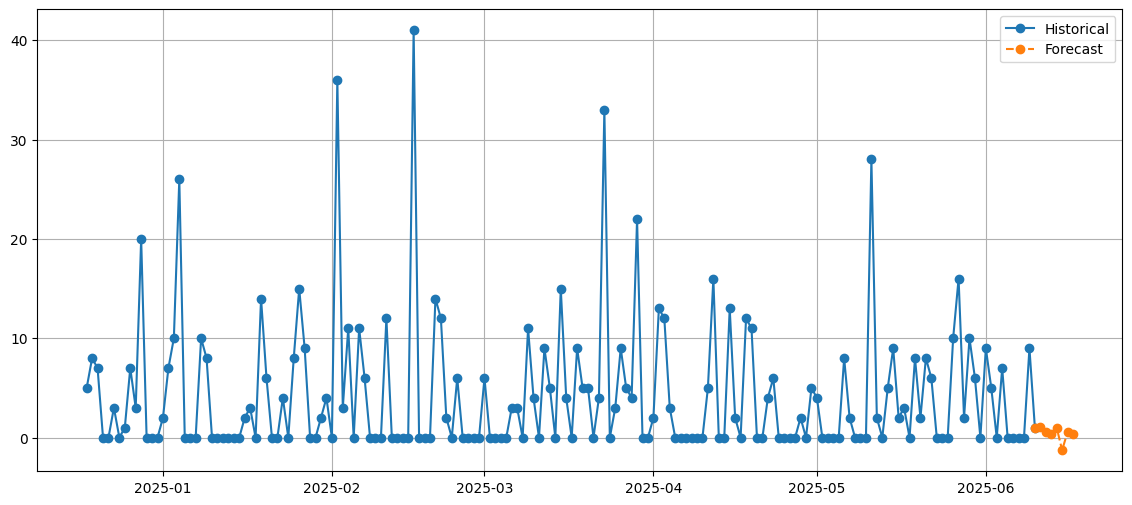

In [46]:
#Plotting smoother graph
plt.figure(figsize=(14,6))

plt.plot(
    history['sale_date'],
    history['demand'],
    label='Historical',
    marker='o'
)

plt.plot(
    future_plot['sale_date'],
    future_plot['pred_demand'],
    label='Forecast',
    marker='o',
    linestyle='--'
)

plt.legend()
plt.grid()
plt.show()

In [47]:
print(master[master['product_id'] == 12])

      product_id  warehouse_id  sale_date  demand  stock_level  stock_change  \
4709          12             2 2024-12-17      11          153           0.0   
4710          12             2 2024-12-18       0          153           0.0   
4711          12             2 2024-12-19       0          153           0.0   
4712          12             2 2024-12-20       8          153           0.0   
4713          12             2 2024-12-21       0          153           0.0   
...          ...           ...        ...     ...          ...           ...   
5055          12             4 2025-06-06       0          153           0.0   
5056          12             4 2025-06-07       0          153           0.0   
5057          12             4 2025-06-08       0          153           0.0   
5058          12             4 2025-06-09       2           88         -65.0   
5059          12             4 2025-06-10      13           88           0.0   

      stockout_flag  day_of_week  month